# Heston Stochastic Volatility Model

## Beyond Constant Volatility

In Chapter 7, we saw that the Merton jump-diffusion model produces a volatility smile by adding sudden jumps to the asset price. Here we take a fundamentally different approach: **make the volatility itself a stochastic process**.

The Heston (1993) model describes the asset price $S_t$ and its instantaneous variance $v_t$ as a coupled system of SDEs:

$$dS_t = r S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S$$
$$dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v$$

with correlated Brownian motions: $\text{Corr}(dW_t^S, dW_t^v) = \rho$.

### The Five Parameters

| Parameter | Meaning | Typical range |
|-----------|---------|---------------|
| $v_0$ | Initial variance | $0.01$–$0.09$ |
| $\kappa$ | Mean-reversion speed of variance | $1$–$5$ |
| $\theta$ | Long-run variance level | $0.01$–$0.09$ |
| $\xi$ | Vol-of-vol (volatility of variance) | $0.1$–$1.0$ |
| $\rho$ | Correlation between $S$ and $v$ | $-0.9$–$0$ |

The **leverage effect** ($\rho < 0$) is the key mechanism: when the stock drops ($dW^S < 0$), volatility tends to rise ($dW^v < 0 \Rightarrow dv > 0$ via the correlation). This creates a left-skewed return distribution and an implied volatility skew — similar to what markets exhibit.

### Heston vs Merton (Chapter 7)

Both models produce volatility smiles, but through different mechanisms:
- **Merton**: Sudden jumps create fat tails. Smile **flattens** at long maturities (jumps average out).
- **Heston**: Stochastic volatility creates vol clustering. Smile **persists** at long maturities.

The Feller condition $2\kappa\theta > \xi^2$ ensures the variance process stays strictly positive.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, log, sqrt, exp, factorial
from scipy.integrate import quad
%matplotlib inline

# Black-Scholes formulas for implied vol inversion
def bs_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def bs_call(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return S * bs_cdf(d1) - K * exp(-r*T) * bs_cdf(d2)

def bs_put(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return -S * bs_cdf(-d1) + K * exp(-r*T) * bs_cdf(-d2)

def implied_vol_newton(market_price, S, K, r, T, is_call=True, tol=1e-8, max_iter=100):
    """Find implied vol via Newton-Raphson."""
    sig = 0.3
    for _ in range(max_iter):
        if is_call:
            price = bs_call(S, K, r, T, sig)
        else:
            price = bs_put(S, K, r, T, sig)
        d1 = (log(S/K) + (r + sig**2/2)*T) / (sig*sqrt(T))
        vega = S * np.exp(-d1**2/2) / sqrt(2*np.pi) * sqrt(T)
        diff = price - market_price
        if abs(diff) < tol:
            return sig
        if vega < 1e-12:
            return np.nan
        sig -= diff / vega
        if sig < 1e-6:
            sig = 1e-6
    return np.nan

## 1. Heston Characteristic Function (Semi-Analytical Pricing)

Heston's key insight was that the model admits a **closed-form characteristic function** for the log-price $\ln S_T$. The European call price can be recovered via Fourier inversion:

$$C = S_0 P_1 - K e^{-rT} P_2$$

where $P_1$ and $P_2$ are obtained from the characteristic function $\phi(u)$:

$$P_j = \frac{1}{2} + \frac{1}{\pi} \int_0^\infty \text{Re}\!\left[ \frac{e^{-iu \ln K} \phi_j(u)}{iu} \right] du$$

We implement this using the formulation of Albrecher et al. (2007) which avoids branch-cut issues in the complex logarithm.

In [2]:
def heston_char_func(u, S0, r, T, v0, kappa, theta, xi, rho, j):
    """
    Heston characteristic function phi_j(u) for j=1,2.
    Uses the formulation that avoids branch-cut discontinuities.
    """
    x = np.log(S0)
    if j == 1:
        b = kappa - rho * xi
        u_adj = 0.5
    else:
        b = kappa
        u_adj = -0.5
    
    d = np.sqrt((rho * xi * 1j * u - b)**2 - xi**2 * (2 * u_adj * 1j * u - u**2))
    g = (b - rho * xi * 1j * u + d) / (b - rho * xi * 1j * u - d)
    
    C = r * 1j * u * T + (kappa * theta / xi**2) * (
        (b - rho * xi * 1j * u + d) * T - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g))
    )
    D = ((b - rho * xi * 1j * u + d) / xi**2) * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))
    
    return np.exp(C + D * v0 + 1j * u * x)


def heston_call(S0, K, r, T, v0, kappa, theta, xi, rho):
    """
    Heston semi-analytical European call price via Fourier inversion.
    """
    def integrand_P(u, j):
        phi = heston_char_func(u, S0, r, T, v0, kappa, theta, xi, rho, j)
        return np.real(np.exp(-1j * u * np.log(K)) * phi / (1j * u))
    
    # Numerical integration
    I1, _ = quad(lambda u: integrand_P(u, 1), 0, 200, limit=200)
    I2, _ = quad(lambda u: integrand_P(u, 2), 0, 200, limit=200)
    
    P1 = 0.5 + I1 / np.pi
    P2 = 0.5 + I2 / np.pi
    
    return S0 * P1 - K * np.exp(-r * T) * P2


def heston_put(S0, K, r, T, v0, kappa, theta, xi, rho):
    """Heston put price via put-call parity."""
    return heston_call(S0, K, r, T, v0, kappa, theta, xi, rho) - S0 + K * np.exp(-r * T)


# Test: compare with BS when xi -> 0 (constant vol)
S0, K, r, T = 100, 100, 0.05, 1.0
v0 = 0.04  # sigma = 0.2 -> v0 = 0.04
kappa, theta, xi, rho = 2.0, 0.04, 1e-6, 0.0  # xi ~ 0 => constant vol

heston_c = heston_call(S0, K, r, T, v0, kappa, theta, xi, rho)
bs_c = bs_call(S0, K, r, T, sqrt(v0))

print("=== Sanity Check: Heston with xi~0 should match BS ===")
print(f"BS call:     {bs_c:.6f}")
print(f"Heston call: {heston_c:.6f}")
print(f"Difference:  {abs(heston_c - bs_c):.2e}")

=== Sanity Check: Heston with xi~0 should match BS ===
BS call:     10.450584
Heston call: 10.450623
Difference:  3.90e-05


/var/folders/0f/vtbxt3h13h1bvn5_vjtd9zfr0000gn/T/ipykernel_48267/2239723127.py:34: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  I1, _ = quad(lambda u: integrand_P(u, 1), 0, 200, limit=200)
/var/folders/0f/vtbxt3h13h1bvn5_vjtd9zfr0000gn/T/ipykernel_48267/2239723127.py:35: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  I2, _ = quad(lambda u: integrand_P(u, 2), 0, 200, limit=200)


## 2. Monte Carlo Simulation of the Heston Model

We simulate the coupled SDEs using Euler discretization. Two key subtleties:

1. **Correlated Brownian motions**: Generate independent $Z_1, Z_2 \sim N(0,1)$, then set:
   $$dW^S = Z_1\sqrt{\Delta t}, \quad dW^v = (\rho Z_1 + \sqrt{1-\rho^2}\,Z_2)\sqrt{\Delta t}$$

2. **Variance positivity**: The Euler scheme can push $v_t$ negative. We use the **absorption** fix: $v_t^+ = \max(v_t, 0)$. This is the simplest approach and works well for moderate parameters.

In [3]:
def simulate_heston(S0, r, T, v0, kappa, theta, xi, rho, n_steps, n_paths):
    """
    Simulate Heston model paths via Euler discretization.
    
    Returns: (S, v) each of shape (n_steps+1, n_paths)
    """
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    
    S = np.zeros((n_steps + 1, n_paths))
    v = np.zeros((n_steps + 1, n_paths))
    S[0] = S0
    v[0] = v0
    
    for t in range(n_steps):
        Z1 = np.random.randn(n_paths)
        Z2 = np.random.randn(n_paths)
        
        # Correlated Brownian increments
        dW_S = Z1 * sqrt_dt
        dW_v = (rho * Z1 + np.sqrt(1 - rho**2) * Z2) * sqrt_dt
        
        # Absorption fix: use max(v, 0) in the diffusion terms
        v_pos = np.maximum(v[t], 0)
        sqrt_v = np.sqrt(v_pos)
        
        # Euler step for S (log scheme for better accuracy)
        S[t+1] = S[t] * np.exp((r - 0.5 * v_pos) * dt + sqrt_v * dW_S)
        
        # Euler step for v
        v[t+1] = v[t] + kappa * (theta - v_pos) * dt + xi * sqrt_v * dW_v
    
    return S, v


# Simulate with realistic Heston parameters
np.random.seed(42)
v0 = 0.04       # initial variance (sigma_0 = 0.2)
kappa = 2.0      # mean-reversion speed
theta = 0.04     # long-run variance
xi = 0.5         # vol-of-vol
rho = -0.7       # leverage effect
n_steps = 252

print(f"Feller condition: 2*kappa*theta = {2*kappa*theta:.4f}, xi^2 = {xi**2:.4f}")
print(f"Feller satisfied: {2*kappa*theta > xi**2} (variance stays positive a.s.)")

S_heston, v_heston = simulate_heston(S0, r, T, v0, kappa, theta, xi, rho, n_steps, 100000)

Feller condition: 2*kappa*theta = 0.1600, xi^2 = 0.2500
Feller satisfied: False (variance stays positive a.s.)


/var/folders/0f/vtbxt3h13h1bvn5_vjtd9zfr0000gn/T/ipykernel_48267/3045656371.py:14: RuntimeWarning: invalid value encountered in sqrt
  ax2.plot(t_grid, np.sqrt(v_heston[:, i]), alpha=0.7, linewidth=0.8)


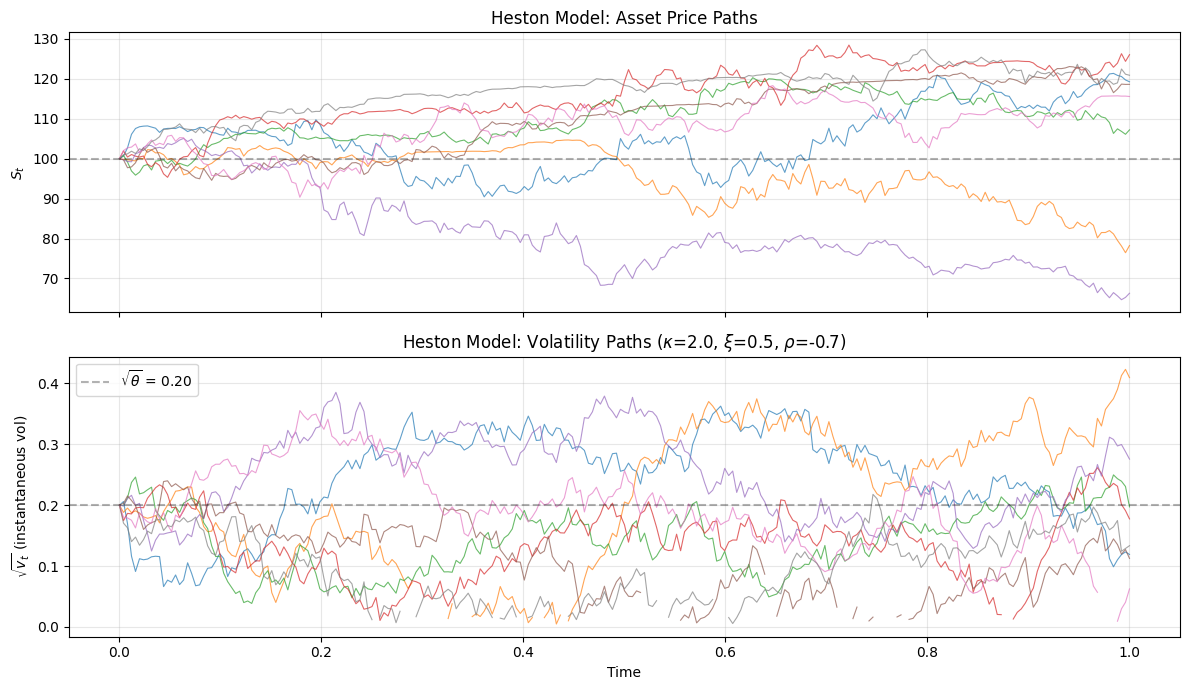

In [4]:
# Plot sample paths
t_grid = np.linspace(0, T, n_steps + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i in range(8):
    ax1.plot(t_grid, S_heston[:, i], alpha=0.7, linewidth=0.8)
ax1.axhline(S0, color='k', linestyle='--', alpha=0.3)
ax1.set_ylabel(r'$S_t$')
ax1.set_title('Heston Model: Asset Price Paths')
ax1.grid(alpha=0.3)

for i in range(8):
    ax2.plot(t_grid, np.sqrt(v_heston[:, i]), alpha=0.7, linewidth=0.8)
ax2.axhline(np.sqrt(theta), color='k', linestyle='--', alpha=0.3, label=rf'$\sqrt{{\theta}}$ = {np.sqrt(theta):.2f}')
ax2.set_xlabel('Time')
ax2.set_ylabel(r'$\sqrt{v_t}$ (instantaneous vol)')
ax2.set_title(r'Heston Model: Volatility Paths ($\kappa$={}, $\xi$={}, $\rho$={})'.format(kappa, xi, rho))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Validate MC Against Semi-Analytical Prices

We compare MC call prices against the Heston characteristic function formula across several strikes.

In [5]:
# MC prices from the simulation
test_strikes = [80, 90, 95, 100, 105, 110, 120]

print("=== Heston: Semi-Analytical vs Monte Carlo ===")
print(f"  Parameters: v0={v0}, kappa={kappa}, theta={theta}, xi={xi}, rho={rho}")
print(f"{'Strike':>8s} {'Analytical':>12s} {'MC (100k)':>12s} {'MC StdErr':>10s} {'Diff':>10s}")

S_T = S_heston[-1]
for Ki in test_strikes:
    # Analytical
    ana = heston_call(S0, Ki, r, T, v0, kappa, theta, xi, rho)
    
    # MC
    payoffs = np.maximum(S_T - Ki, 0)
    disc = np.exp(-r * T) * payoffs
    mc = np.mean(disc)
    mc_err = np.std(disc) / np.sqrt(len(disc))
    
    print(f"{Ki:8.0f} {ana:12.6f} {mc:12.6f} {mc_err:10.6f} {mc - ana:10.6f}")

=== Heston: Semi-Analytical vs Monte Carlo ===
  Parameters: v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho=-0.7
  Strike   Analytical    MC (100k)  MC StdErr       Diff
      80    25.236764    25.243886   0.049642   0.007121
      90    17.140055    17.149133   0.043327   0.009078
      95    13.474244    13.483091   0.039316   0.008848
     100    10.154627    10.162501   0.034775   0.007874
     105     7.259906     7.266267   0.029813   0.006361
     110     4.866183     4.865525   0.024643  -0.000657
     120     1.738232     1.732405   0.014885  -0.005827


## 4. The Implied Volatility Surface

The Heston model produces a rich implied volatility surface. We compute call prices across a grid of strikes and maturities, invert each to get implied vol.

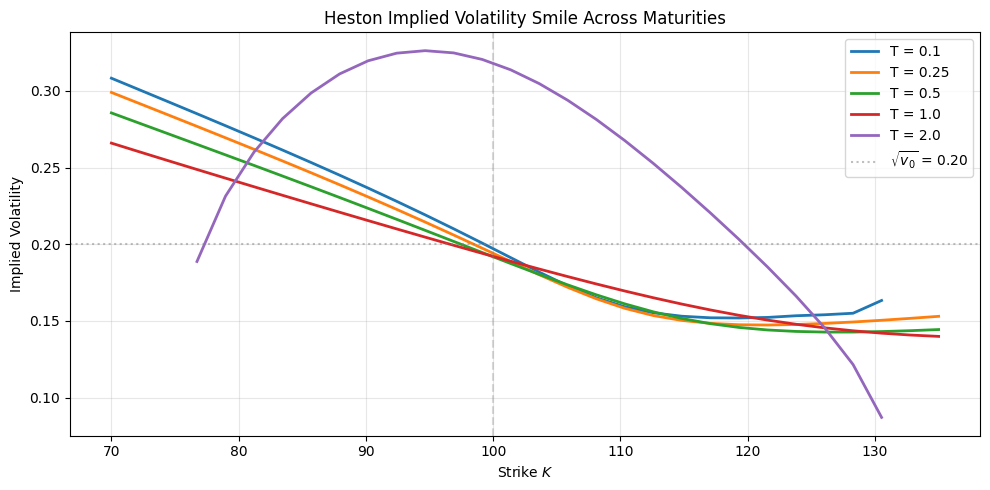

In [6]:
# Compute implied vol surface from Heston analytical prices
strikes = np.linspace(70, 135, 30)
maturities = [0.1, 0.25, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(10, 5))

for T_i in maturities:
    ivs = []
    for Ki in strikes:
        if Ki < S0:
            hp = heston_put(S0, Ki, r, T_i, v0, kappa, theta, xi, rho)
            iv = implied_vol_newton(hp, S0, Ki, r, T_i, is_call=False)
        else:
            hc = heston_call(S0, Ki, r, T_i, v0, kappa, theta, xi, rho)
            iv = implied_vol_newton(hc, S0, Ki, r, T_i, is_call=True)
        ivs.append(iv)
    ax.plot(strikes, ivs, linewidth=2, label=f'T = {T_i}')

ax.axhline(np.sqrt(v0), color='gray', linestyle=':', alpha=0.5, label=rf'$\sqrt{{v_0}}$ = {np.sqrt(v0):.2f}')
ax.axvline(S0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Strike $K$')
ax.set_ylabel('Implied Volatility')
ax.set_title('Heston Implied Volatility Smile Across Maturities')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

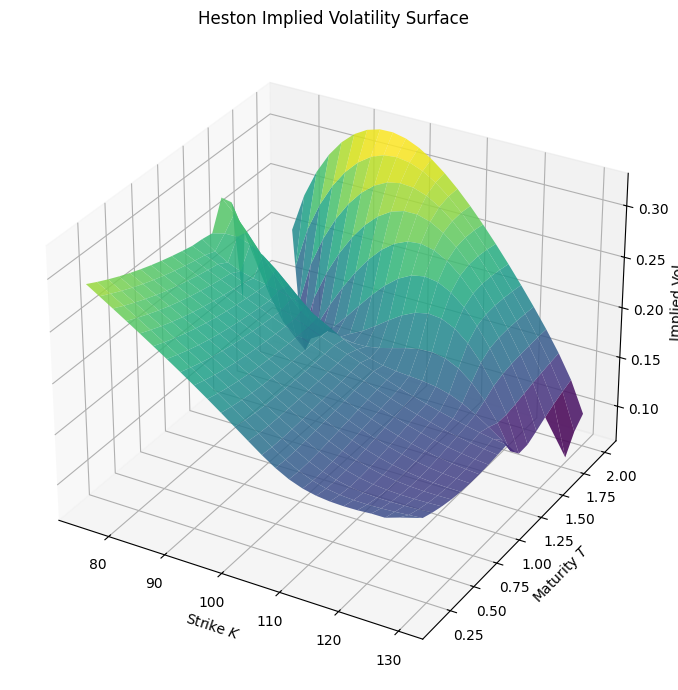

In [7]:
# 3D implied volatility surface
strikes_3d = np.linspace(75, 130, 25)
maturities_3d = np.linspace(0.1, 2.0, 20)
K_grid, T_grid = np.meshgrid(strikes_3d, maturities_3d)

iv_surface = np.zeros_like(K_grid)
for i in range(len(maturities_3d)):
    for j in range(len(strikes_3d)):
        Ki, Ti = strikes_3d[j], maturities_3d[i]
        if Ki < S0:
            hp = heston_put(S0, Ki, r, Ti, v0, kappa, theta, xi, rho)
            iv_surface[i, j] = implied_vol_newton(hp, S0, Ki, r, Ti, is_call=False)
        else:
            hc = heston_call(S0, Ki, r, Ti, v0, kappa, theta, xi, rho)
            iv_surface[i, j] = implied_vol_newton(hc, S0, Ki, r, Ti, is_call=True)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_grid, T_grid, iv_surface, cmap='viridis', alpha=0.85)
ax.set_xlabel('Strike $K$')
ax.set_ylabel('Maturity $T$')
ax.set_zlabel('Implied Vol')
ax.set_title('Heston Implied Volatility Surface')
plt.tight_layout()
plt.show()

## 5. Parameter Sensitivity

Each Heston parameter shapes the implied volatility surface differently:

- **$\rho$ (correlation)**: Controls the **skew**. $\rho < 0$ tilts the smile leftward.
- **$\xi$ (vol-of-vol)**: Controls the **curvature**. Higher $\xi$ = more pronounced smile.
- **$\kappa$ (mean-reversion)**: Controls the **term structure**. Faster mean reversion flattens the smile at long maturities.

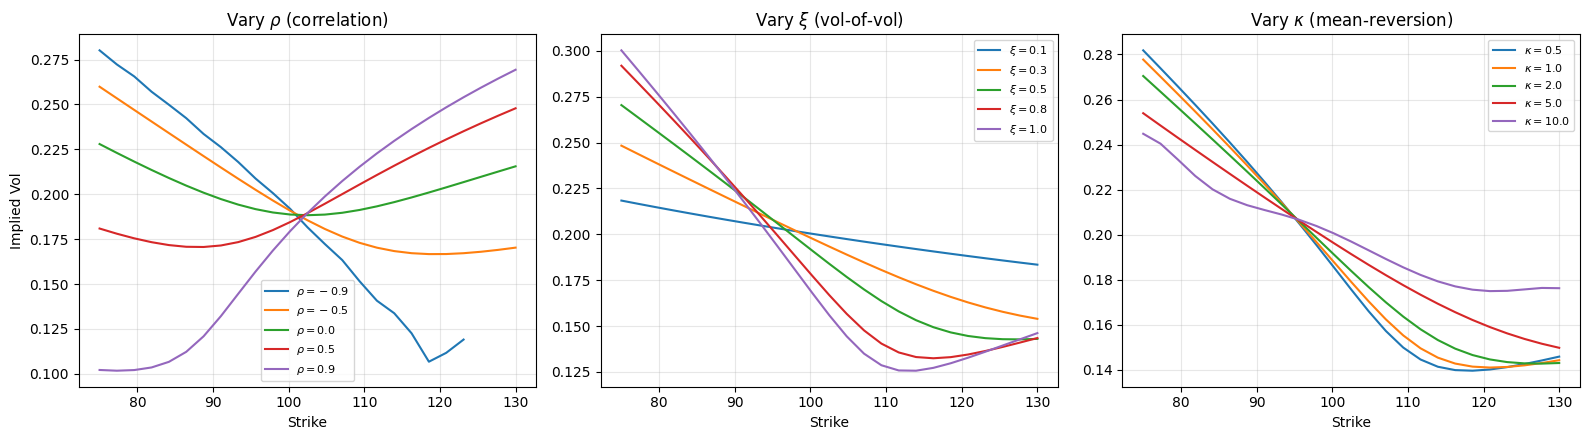

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
strikes_sens = np.linspace(75, 130, 25)
T_sens = 0.5

# (a) Vary rho
for rho_i in [-0.9, -0.5, 0.0, 0.5, 0.9]:
    ivs = []
    for Ki in strikes_sens:
        if Ki < S0:
            p = heston_put(S0, Ki, r, T_sens, v0, kappa, theta, xi, rho_i)
            ivs.append(implied_vol_newton(p, S0, Ki, r, T_sens, is_call=False))
        else:
            p = heston_call(S0, Ki, r, T_sens, v0, kappa, theta, xi, rho_i)
            ivs.append(implied_vol_newton(p, S0, Ki, r, T_sens, is_call=True))
    axes[0].plot(strikes_sens, ivs, linewidth=1.5, label=rf'$\rho={rho_i}$')
axes[0].set_title(r'Vary $\rho$ (correlation)')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Vol')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# (b) Vary xi
for xi_i in [0.1, 0.3, 0.5, 0.8, 1.0]:
    ivs = []
    for Ki in strikes_sens:
        if Ki < S0:
            p = heston_put(S0, Ki, r, T_sens, v0, kappa, theta, xi_i, rho)
            ivs.append(implied_vol_newton(p, S0, Ki, r, T_sens, is_call=False))
        else:
            p = heston_call(S0, Ki, r, T_sens, v0, kappa, theta, xi_i, rho)
            ivs.append(implied_vol_newton(p, S0, Ki, r, T_sens, is_call=True))
    axes[1].plot(strikes_sens, ivs, linewidth=1.5, label=rf'$\xi={xi_i}$')
axes[1].set_title(r'Vary $\xi$ (vol-of-vol)')
axes[1].set_xlabel('Strike')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# (c) Vary kappa
for kappa_i in [0.5, 1.0, 2.0, 5.0, 10.0]:
    ivs = []
    for Ki in strikes_sens:
        if Ki < S0:
            p = heston_put(S0, Ki, r, T_sens, v0, kappa_i, theta, xi, rho)
            ivs.append(implied_vol_newton(p, S0, Ki, r, T_sens, is_call=False))
        else:
            p = heston_call(S0, Ki, r, T_sens, v0, kappa_i, theta, xi, rho)
            ivs.append(implied_vol_newton(p, S0, Ki, r, T_sens, is_call=True))
    axes[2].plot(strikes_sens, ivs, linewidth=1.5, label=rf'$\kappa={kappa_i}$')
axes[2].set_title(r'Vary $\kappa$ (mean-reversion)')
axes[2].set_xlabel('Strike')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Heston vs Merton: Two Roads to the Smile

Both models generate implied volatility smiles, but through fundamentally different mechanisms. A key empirical difference: how the smile behaves as maturity increases.

- **Merton** (jumps): At long maturities, jumps average out by the law of large numbers, so the smile **flattens** toward constant BS vol.
- **Heston** (stochastic vol): Volatility clustering persists at all horizons, so the smile **remains** even at long maturities.

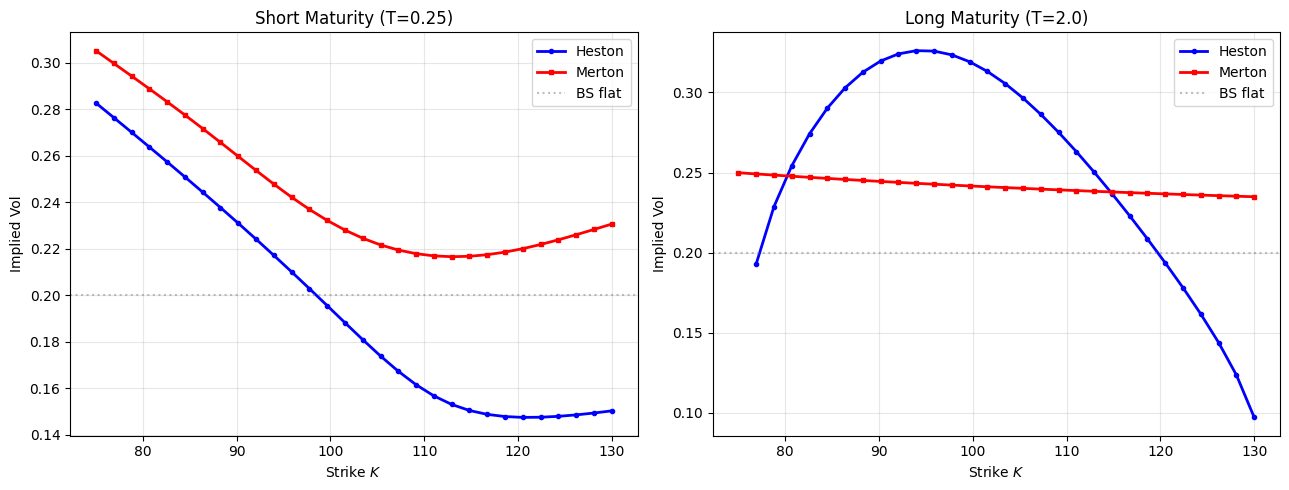

Short maturity: both models produce strong smiles.
Long maturity: Merton smile flattens (jumps average out),
               Heston smile persists (vol clustering continues).


In [9]:
# Merton analytical formula (from Chapter 7)
def merton_call(S0, K, r, T, sigma, lam, mu_J, sigma_J, n_terms=50):
    k_bar = exp(mu_J + 0.5 * sigma_J**2) - 1
    lam_prime = lam * (1 + k_bar)
    price = 0.0
    for n in range(n_terms):
        sigma_n = sqrt(sigma**2 + n * sigma_J**2 / T)
        r_n = r - lam * k_bar + n * log(1 + k_bar) / T
        w = exp(-lam_prime * T) * (lam_prime * T)**n / factorial(n)
        price += w * bs_call(S0, K, r_n, T, sigma_n)
    return price

def merton_put(S0, K, r, T, sigma, lam, mu_J, sigma_J, n_terms=50):
    k_bar = exp(mu_J + 0.5 * sigma_J**2) - 1
    lam_prime = lam * (1 + k_bar)
    price = 0.0
    for n in range(n_terms):
        sigma_n = sqrt(sigma**2 + n * sigma_J**2 / T)
        r_n = r - lam * k_bar + n * log(1 + k_bar) / T
        w = exp(-lam_prime * T) * (lam_prime * T)**n / factorial(n)
        price += w * bs_put(S0, K, r_n, T, sigma_n)
    return price

# Merton parameters (from Chapter 7)
sigma_m = 0.15
lam = 3.0
mu_J = -0.05
sigma_J = 0.1

# Compare smiles at short and long maturities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
strikes_cmp = np.linspace(75, 130, 30)

for T_i, ax, title in [(0.25, ax1, 'Short Maturity (T=0.25)'), (2.0, ax2, 'Long Maturity (T=2.0)')]:
    # Heston IV
    iv_heston = []
    for Ki in strikes_cmp:
        if Ki < S0:
            hp = heston_put(S0, Ki, r, T_i, v0, kappa, theta, xi, rho)
            iv_heston.append(implied_vol_newton(hp, S0, Ki, r, T_i, is_call=False))
        else:
            hc = heston_call(S0, Ki, r, T_i, v0, kappa, theta, xi, rho)
            iv_heston.append(implied_vol_newton(hc, S0, Ki, r, T_i, is_call=True))
    
    # Merton IV
    iv_merton = []
    for Ki in strikes_cmp:
        if Ki < S0:
            mp = merton_put(S0, Ki, r, T_i, sigma_m, lam, mu_J, sigma_J)
            iv_merton.append(implied_vol_newton(mp, S0, Ki, r, T_i, is_call=False))
        else:
            mc = merton_call(S0, Ki, r, T_i, sigma_m, lam, mu_J, sigma_J)
            iv_merton.append(implied_vol_newton(mc, S0, Ki, r, T_i, is_call=True))
    
    ax.plot(strikes_cmp, iv_heston, 'b-o', markersize=3, linewidth=2, label='Heston')
    ax.plot(strikes_cmp, iv_merton, 'r-s', markersize=3, linewidth=2, label='Merton')
    ax.axhline(np.sqrt(v0), color='gray', linestyle=':', alpha=0.5, label='BS flat')
    ax.set_xlabel('Strike $K$')
    ax.set_ylabel('Implied Vol')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Short maturity: both models produce strong smiles.")
print("Long maturity: Merton smile flattens (jumps average out),")
print("               Heston smile persists (vol clustering continues).")

## Summary

The Heston stochastic volatility model extends Black-Scholes by making variance a mean-reverting stochastic process:

| Property | Black-Scholes | Merton (Ch.7) | Heston |
|----------|:------------:|:-------------:|:------:|
| Volatility | Constant $\sigma$ | Constant + jumps | Stochastic $\sqrt{v_t}$ |
| Smile mechanism | None (flat IV) | Fat tails from jumps | Leverage effect ($\rho < 0$) |
| Smile at long T | Flat | Flattens | Persists |
| Analytical prices | Yes | Yes (series) | Yes (Fourier) |
| Parameters | 1 ($\sigma$) | 3 ($\lambda, \mu_J, \sigma_J$) | 5 ($v_0, \kappa, \theta, \xi, \rho$) |

Key takeaways:
- $\rho < 0$ creates the **skew**: stock drops $\Rightarrow$ vol rises (leverage effect)
- $\xi$ controls **smile curvature**: higher vol-of-vol $\Rightarrow$ more pronounced smile
- $\kappa$ controls **term structure**: fast mean reversion $\Rightarrow$ smile flattens at long maturities
- Unlike Merton, the Heston smile **persists** at long horizons — matching empirical observations
- The Feller condition $2\kappa\theta > \xi^2$ ensures variance stays positive